### Imports

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from deep_drawing.pipeline import cross_correlation

%load_ext autoreload
%autoreload 2
#%matplotlib inline
%xmode Verbose

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Exception reporting mode: Verbose


### Init buffer and audio

In [23]:
audio_buffer = cross_correlation.LiveAudioBuffer(channels=2, window_size=100, hop_size=1)
audio_buffer.push_audio_from_files((
    "trial_1b.wav", "trial_1c.wav"
))

print(audio_buffer.buffer.shape)

(2, 1587302)


### Plotting waveforms

In [24]:
XLIM = (0, 30)

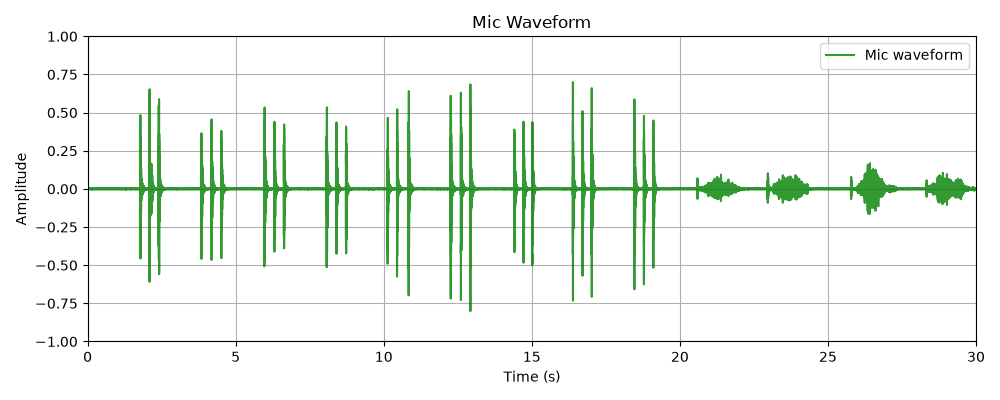

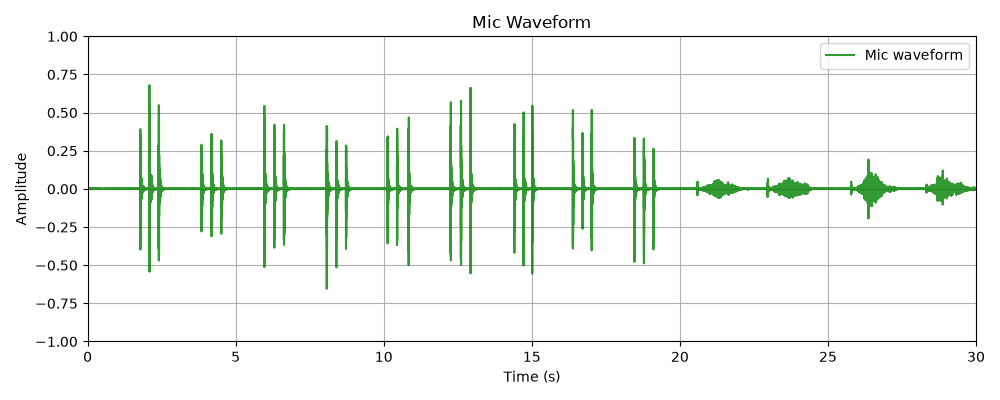

In [25]:
def plot_waveform(waveform):
    """Plot waveform."""
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(waveform)) / 48000, waveform, label='Mic waveform', color='g', alpha=0.8)
    #plt.axhline(0, color='r', linestyle='--', label='Zero amplitude')
    plt.title('Mic Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.xlim(XLIM)
    plt.ylim((-1, 1))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_waveform(cross_correlation.apply_low_cut(cross_correlation.input_from_audio("trial_1a.wav")))
plot_waveform(cross_correlation.apply_low_cut(cross_correlation.input_from_audio("trial_1b.wav")))

### Plotting cross-correlation time lag

In [26]:
def plot_tdoa_tracking(timestamps, delays_in_samples):
    """Plot max correlation delay over time to evaluate noise and tracking."""
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, delays_in_samples, label='Measured delay (samples)', color='b', alpha=0.8)
    plt.axhline(0, color='r', linestyle='--', label='Zero delay')
    plt.title('Time-Domain Cross-Correlation Delay Tracking (Mic 1 vs Mic 2)')
    plt.xlabel('Time (s)')
    plt.ylabel('Delay offset (samples)')
    plt.xlim(XLIM)
    plt.ylim((-1000, 1000))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

#plot_tdoa_tracking(*(audio_buffer.compute_pair_tdoa_tracking_time_domain()))

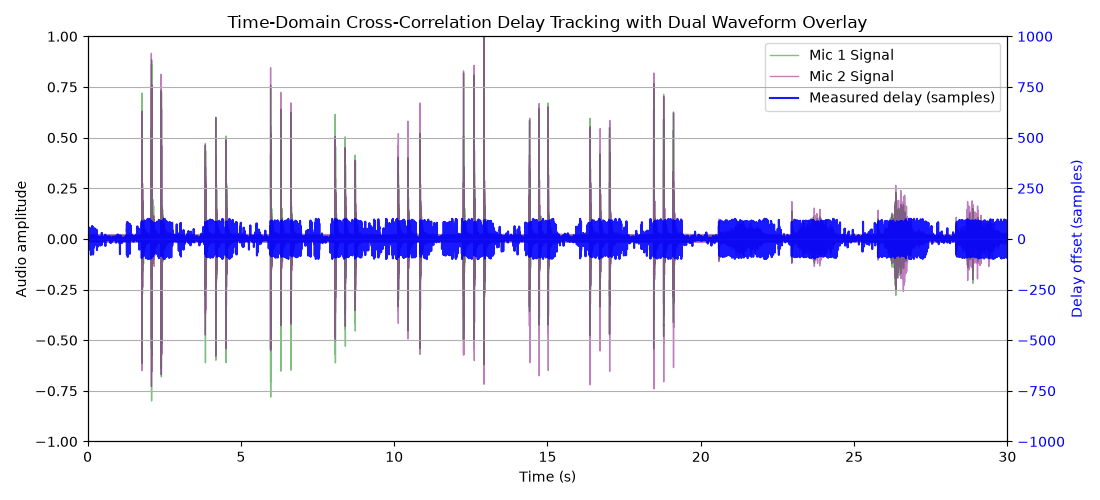

In [27]:
def plot_tdoa_and_waveforms(timestamps, delays_in_samples, wave_a, wave_b, xlim=None, sample_rate=48000):
    """
    Plots two microphone waveforms on the left Y-axis and 
    cross-correlation delay tracking on the right Y-axis.
    """
    fig, ax_audio = plt.subplots(figsize=(11, 5))

    # Time axes for audio signals
    time_audio = np.arange(len(wave_a)) / sample_rate

    # --- Left Y-Axis: Microphone Waveforms ---
    line_a = ax_audio.plot(time_audio, wave_a, label='Mic 1 Signal', color='g', alpha=0.5, linewidth=1)
    line_b = ax_audio.plot(time_audio, wave_b, label='Mic 2 Signal', color='purple', alpha=0.5, linewidth=1)

    ax_audio.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax_audio.set_xlabel('Time (s)')
    ax_audio.set_ylabel('Audio amplitude', color='black')
    ax_audio.set_ylim((-1, 1))

    # --- Right Y-Axis: Delay Tracking ---
    ax_delay = ax_audio.twinx()
    line_delay = ax_delay.plot(timestamps, delays_in_samples, label='Measured delay (samples)', color='b', alpha=0.9, linewidth=1.5)
    #line_zero = ax_delay.axhline(0, color='r', linestyle='--', label='Zero delay', alpha=0.7)

    ax_delay.set_ylabel('Delay offset (samples)', color='b')
    ax_delay.tick_params(axis='y', labelcolor='b')
    ax_delay.set_ylim((-1000, 1000))

    # Apply X limits if passed
    if xlim is not None:
        ax_audio.set_xlim(xlim)

    # Combine legends from both Y-axes into one legend box
    lines = line_a + line_b + line_delay# + [line_zero]
    labels = [line.get_label() for line in lines]
    ax_audio.legend(lines, labels, loc='upper right')

    plt.title('Time-Domain Cross-Correlation Delay Tracking with Dual Waveform Overlay')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


wave_a = cross_correlation.input_from_audio("trial_1b.wav")
wave_b = cross_correlation.input_from_audio("trial_1c.wav")
timestamps, delays_samples = audio_buffer.compute_pair_tdoa_tracking_time_domain()

%matplotlib widget
plot_tdoa_and_waveforms(timestamps, delays_samples, wave_a, wave_b, xlim=XLIM)

In [28]:
PLYWOOD_SIDE_LENGTH = 0.6  # m


# Guesstimates
MIN_SPEED_OF_SOUND = 343  # strict lower bound for m/s of sound in plywood
MAX_TDOA = PLYWOOD_SIDE_LENGTH * np.sqrt(2) / MIN_SPEED_OF_SOUND  # s, about 0.84 ms
MAX_TDOA_IN_AUDIO_SAMPLES = MAX_TDOA * 48000  # samples, about 40.72

print(MAX_TDOA_IN_AUDIO_SAMPLES)

118.74446238001498
